In [ ]:
# Run once at top of Colab
!pip install -q xgboost imbalanced-learn joblib streamlit fpdf seaborn matplotlib


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 40.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE


In [ ]:
from google.colab import files
print("Upload Stress.csv now (choose file).")
uploaded = files.upload()

fname = list(uploaded.keys())[0]
df = pd.read_csv(fname)
print("Loaded file:", fname, "shape:", df.shape)
df.head()


Upload Stress.csv now (choose file).


Saving Stress.csv to Stress.csv
Loaded file: Stress.csv shape: (2028, 19)


,1. Age,2. Gender,3. University,4. Department,5. Academic Year,6. Current CGPA,7. Did you receive a waiver or scholarship at your university?,"1. In a semester, how often have you felt upset due to something that happened in your academic affairs?","2. In a semester, how often you felt as if you were unable to control important things in your academic affairs?","3. In a semester, how often you felt nervous and stressed because of academic pressure?","4. In a semester, how often you felt as if you could not cope with all the mandatory academic activities? (e.g, assignments, quiz, exams)","5. In a semester, how often you felt confident about your ability to handle your academic / university problems?","6. In a semester, how often you felt as if things in your academic life is going on your way?","7. In a semester, how often are you able to control irritations in your academic / university affairs?","8. In a semester, how often you felt as if your academic performance was on top?","9. In a semester, how often you got angered due to bad performance or low grades that is beyond your control?","10. In a semester, how often you felt as if academic difficulties are piling up so high that you could not overcome them?",Stress Value,Stress Label
0,18-22,Female,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Second Year or Equivalent,2.50 - 2.99,No,3,4,3,2,2,1,2,2,4,4,29,High Perceived Stress
1,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,3,3,4,2,3,2,2,2,2,3,24,Moderate Stress
2,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,0,0,0,0,0,1,0,0,0,0,15,Moderate Stress
3,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,3,1,2,1,4,3,2,2,3,2,17,Moderate Stress
4,18-22,Male,North South University (NSU),Engineering - CS / CSE / CSC / Similar to CS,Second Year or Equivalent,2.50 - 2.99,No,4,4,4,2,2,2,0,2,4,4,32,High Perceived Stress


In [ ]:

orig_cols = df.columns.tolist()
col_map = {
    '1. Age':'Age',
    '2. Gender':'Gender',
    '5. Academic Year':'Academic_Year',
    '6. Current CGPA':'CGPA',
    '7. Did you receive a waiver or scholarship at your university?':'Scholarship',
    'Stress Label':'Stress_Label',
    'Stress Value':'Stress_Value'
}

# Try to detect the 10 question columns heuristically (text contains "how often" or "In a semester")
q_candidates = [c for c in orig_cols if ('how often' in c.lower()) or ('in a semester' in c.lower()) or c.strip().startswith('8.') or c.strip().startswith('Q')]


if len(q_candidates) < 10 and len(orig_cols) >= 17:
    q_candidates = orig_cols[7:17]

q_candidates = q_candidates[:10]

for i, qc in enumerate(q_candidates, 1):
    col_map.setdefault(qc, f"Q{i}")

df = df.rename(columns=col_map)
print("Renamed columns applied. New columns:")
print(df.columns.tolist())


Renamed columns applied. New columns:
['Age', 'Gender', '3. University', '4. Department', 'Academic_Year', 'CGPA', 'Scholarship', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Stress_Value', 'Stress_Label']


In [ ]:
required = ['Age','Gender','Academic_Year','CGPA','Scholarship'] + [f"Q{i}" for i in range(1,11)] + ['Stress_Label']
missing = [c for c in required if c not in df.columns]
if missing:
    print("Missing required columns:", missing)
    print("Current columns:", df.columns.tolist())
    raise SystemExit("Please re-check dataset column names or upload the correct file.")
print("All required columns present. Sample:")
df[required].head()


All required columns present. Sample:


,Age,Gender,Academic_Year,CGPA,Scholarship,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Stress_Label
0,18-22,Female,Second Year or Equivalent,2.50 - 2.99,No,3,4,3,2,2,1,2,2,4,4,High Perceived Stress
1,18-22,Male,Third Year or Equivalent,3.00 - 3.39,No,3,3,4,2,3,2,2,2,2,3,Moderate Stress
2,18-22,Male,Third Year or Equivalent,3.00 - 3.39,No,0,0,0,0,0,1,0,0,0,0,Moderate Stress
3,18-22,Male,Third Year or Equivalent,3.00 - 3.39,No,3,1,2,1,4,3,2,2,3,2,Moderate Stress
4,18-22,Male,Second Year or Equivalent,2.50 - 2.99,No,4,4,4,2,2,2,0,2,4,4,High Perceived Stress


In [ ]:
# Normalize target labels
df['Stress_Label'] = df['Stress_Label'].astype(str).str.strip()
df['Stress_Label'] = df['Stress_Label'].replace({
    'High Perceived Stress': 'High Stress',
    'High stress': 'High Stress',
    'high stress': 'High Stress',
    'Moderate stress': 'Moderate Stress',
    'moderate stress': 'Moderate Stress',
    'Low stress': 'Low Stress',
    'low stress': 'Low Stress'
})

print("Label counts (raw):")
print(df['Stress_Label'].value_counts())

# Force Q1..Q10 to numeric and fill missing
for i in range(1,11):
    q = f"Q{i}"
    df[q] = pd.to_numeric(df[q], errors='coerce')
    # if numeric conversion created NaN, fill with mode
    if df[q].isna().any():
        df[q] = df[q].fillna(df[q].mode().iloc[0])
    df[q] = df[q].astype(int)

# Demographics: ensure exist and fillna
for c in ['Age','Gender','Academic_Year','CGPA','Scholarship']:
    if c in df.columns:
        df[c] = df[c].fillna(df[c].mode().iloc[0]).astype(str)


Label counts (raw):
Stress_Label
Moderate Stress    1348
High Stress         565
Low Stress          115
Name: count, dtype: int64


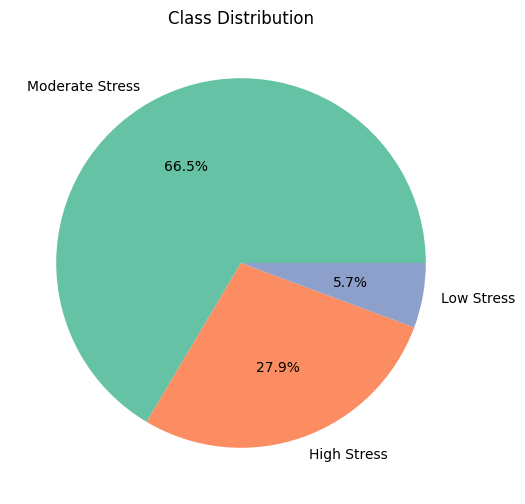

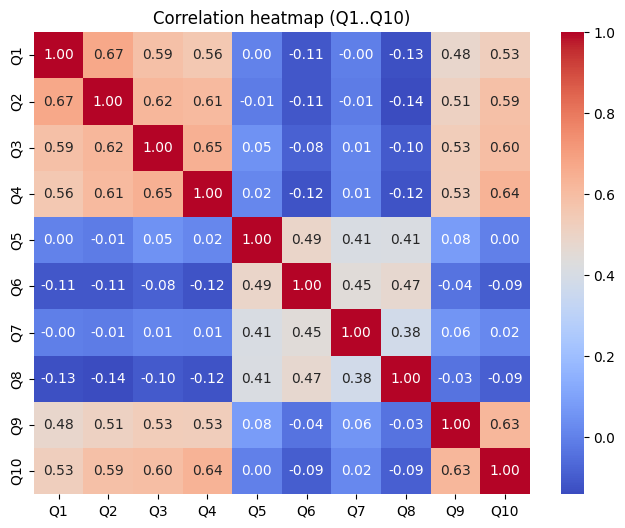

In [ ]:
# class distribution
plt.figure(figsize=(6,6))
df['Stress_Label'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette("Set2"))
plt.title("Class Distribution")
plt.ylabel('')
plt.savefig("class_distribution.png", bbox_inches='tight')
plt.show()

# correlation heatmap on numeric columns (demographics encoded later — show Qs corr)
num_for_corr = [f"Q{i}" for i in range(1,11)]
corr = df[num_for_corr].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation heatmap (Q1..Q10)")
plt.savefig("corr_heatmap_qs.png", bbox_inches='tight')
plt.show()


In [ ]:
# Label-encode demographic categorical features
le_dict = {}
for c in ['Age','Gender','Academic_Year','CGPA','Scholarship']:
    if c in df.columns:
        le = LabelEncoder()
        df[c] = le.fit_transform(df[c].astype(str))
        le_dict[c] = le

# Encode target
target_le = LabelEncoder()
df['y'] = target_le.fit_transform(df['Stress_Label'])

# Construct feature matrix X using ALL requested columns
feature_cols = ['Age','Gender','Academic_Year','CGPA','Scholarship'] + [f"Q{i}" for i in range(1,11)]
X = df[feature_cols].copy()
y = df['y'].copy()

print("Features shape:", X.shape)
print("Target distribution:", dict(zip(target_le.classes_, np.bincount(y))))


Features shape: (2028, 15)
Target distribution: {'High Stress': np.int64(565), 'Low Stress': np.int64(115), 'Moderate Stress': np.int64(1348)}


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("Train counts:", np.bincount(y_train), "Test counts:", np.bincount(y_test))


Train counts: [ 452   92 1078] Test counts: [113  23 270]


In [ ]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
print("After SMOTE train counts:", np.bincount(y_res))


After SMOTE train counts: [1078 1078 1078]


In [ ]:
# ---------------------
# Cell 11 — Train 3 Models (XGBoost 2.x compatible)
# ---------------------

# Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_res, y_res)
pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)
print("RF accuracy:", acc_rf)

# XGBoost (2.x version: eval_metric moved OUT of fit)
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=6,
    random_state=42,
    objective='multi:softprob',     # proper for multiclass
    num_class=len(np.unique(y))     # number of stress classes
)

evals_result = {}

# Fit WITHOUT eval_metric argument
xgb.fit(
    X_res,
    y_res,
    eval_set=[(X_res, y_res), (X_test, y_test)],
    verbose=False
)

# Now manually compute loss curve for train/test
from sklearn.metrics import log_loss

train_losses = []
test_losses = []

pred_train_prob = xgb.predict_proba(X_res)
pred_test_prob = xgb.predict_proba(X_test)

train_loss = log_loss(y_res, pred_train_prob)
test_loss = log_loss(y_test, pred_test_prob)

train_losses.append(train_loss)
test_losses.append(test_loss)

pred_xgb = xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, pred_xgb)
print("XGB accuracy:", acc_xgb)

# Logistic Regression (scaled)
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=2000,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=42
)
lr.fit(X_res_scaled, y_res)
pred_lr = lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, pred_lr)
print("LR accuracy:", acc_lr)

# store models and results
models = {'rf': rf, 'xgb': xgb, 'lr': lr}
accuracies = {'rf': acc_rf, 'xgb': acc_xgb, 'lr': acc_lr}

# store for XGB loss curve
xgb_loss_curve = {"train": train_losses, "test": test_losses}


RF accuracy: 0.9532019704433498
XGB accuracy: 0.9482758620689655
LR accuracy: 0.9876847290640394


In [ ]:
best_name = max(accuracies, key=accuracies.get)
best_acc = accuracies[best_name]
print("Accuracies:", accuracies)
print("Best model by accuracy:", best_name, best_acc)

best_model = models[best_name]
# Save encoders + scaler if LR is best
save_obj = {'target_le': target_le, 'feature_cols': feature_cols}
if best_name == 'lr':
    save_obj['scaler'] = scaler

joblib.dump(best_model, "best_model.pkl")
joblib.dump({**save_obj, **{'label_encoders': le_dict}}, "encoders.pkl")
print("Saved best_model.pkl and encoders.pkl")


Accuracies: {'rf': 0.9532019704433498, 'xgb': 0.9482758620689655, 'lr': 0.9876847290640394}
Best model by accuracy: lr 0.9876847290640394
Saved best_model.pkl and encoders.pkl


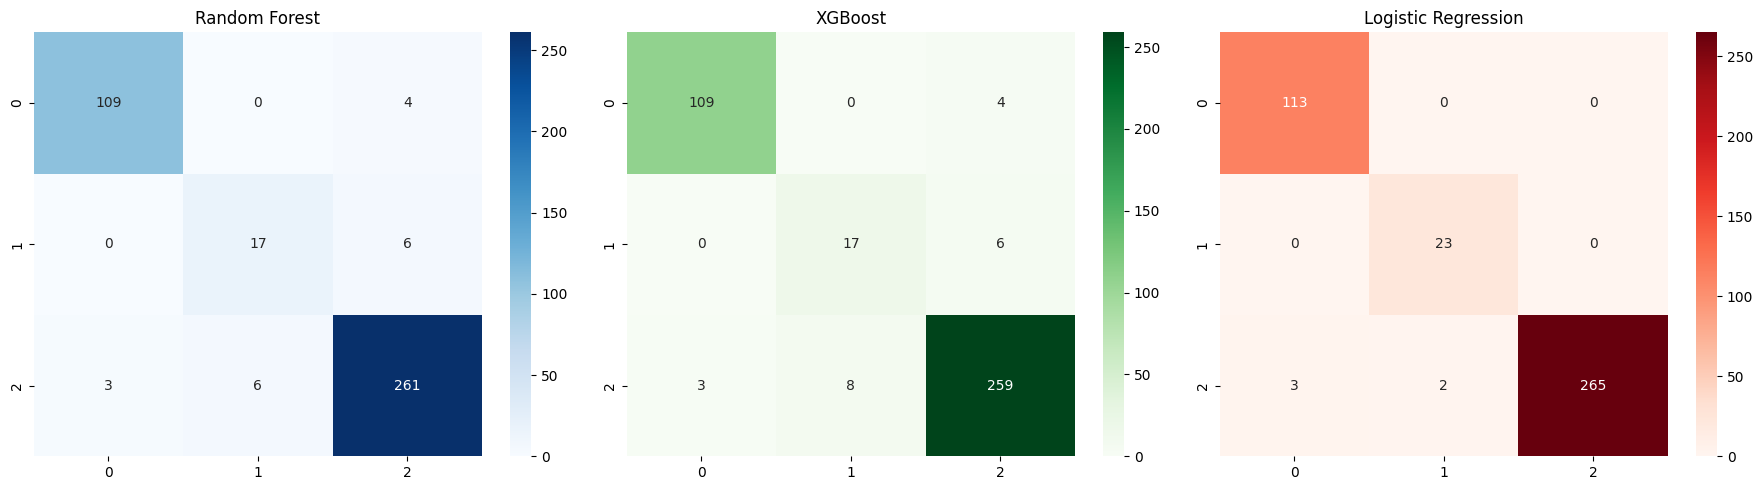

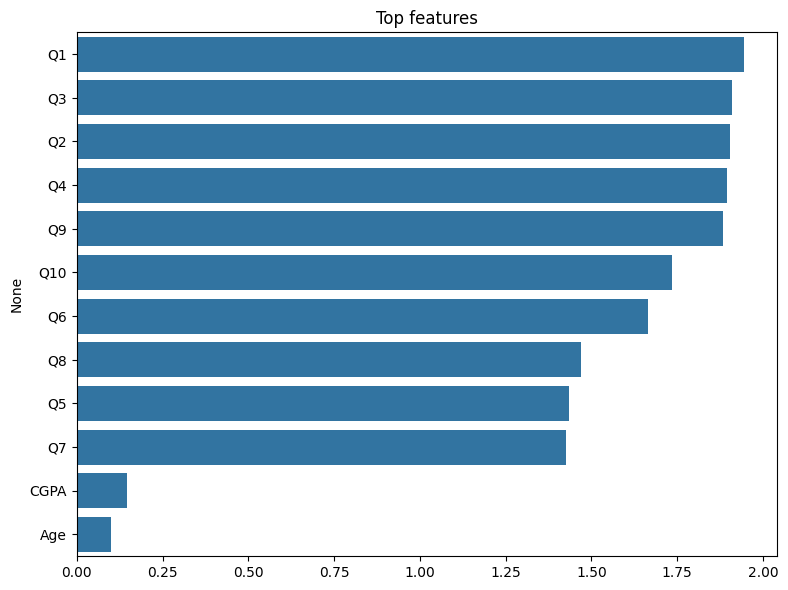

No XGBoost evals_result available for loss curve.


In [ ]:
# Confusion matrices
fig, axes = plt.subplots(1,3, figsize=(18,5))
sns.heatmap(confusion_matrix(y_test, pred_rf), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title("Random Forest")
sns.heatmap(confusion_matrix(y_test, pred_xgb), annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title("XGBoost")
sns.heatmap(confusion_matrix(y_test, pred_lr), annot=True, fmt='d', ax=axes[2], cmap='Reds')
axes[2].set_title("Logistic Regression")
plt.tight_layout()
plt.savefig("confusion_matrices.png", bbox_inches='tight')
plt.show()

# Feature importances (from best model if tree-based or from LR coef magnitude)
feat_names = X.columns.tolist()
if best_name in ['rf','xgb']:
    importances = best_model.feature_importances_
    fi = pd.Series(importances, index=feat_names).sort_values(ascending=False)
else:
    # lr coefficients (absolute mean across classes)
    coefs = np.abs(best_model.coef_).mean(axis=0)
    fi = pd.Series(coefs, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=fi.values[:12], y=fi.index[:12])
plt.title("Top features")
plt.tight_layout()
plt.savefig("feature_importances.png", bbox_inches='tight')
plt.show()

# XGBoost logloss curve (if available)
if 'validation_1' in evals_result and 'mlogloss' in evals_result['validation_1']:
    train_loss = evals_result['validation_0']['mlogloss']
    test_loss = evals_result['validation_1']['mlogloss']
    rounds = list(range(1, len(train_loss)+1))
    plt.figure(figsize=(8,5))
    plt.plot(rounds, train_loss, label='train mlogloss')
    plt.plot(rounds, test_loss, label='test mlogloss')
    plt.xlabel("Boosting Round")
    plt.ylabel("Log Loss")
    plt.title("XGBoost LogLoss per round (like epoch curve)")
    plt.legend()
    plt.grid(True)
    plt.savefig("xgb_logloss_curve.png", bbox_inches='tight')
    plt.show()
else:
    print("No XGBoost evals_result available for loss curve.")


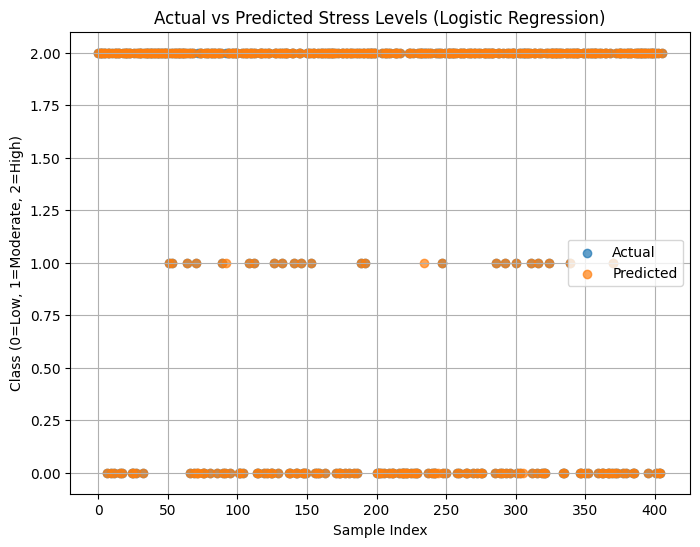

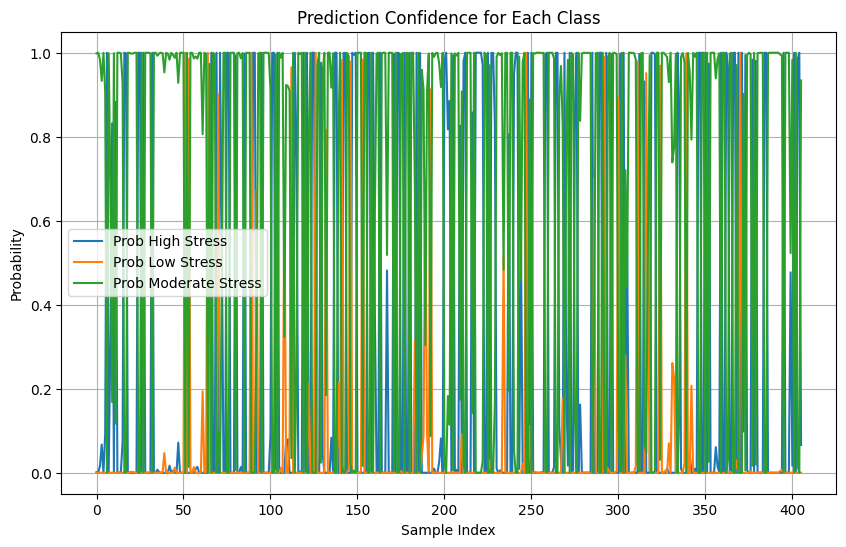

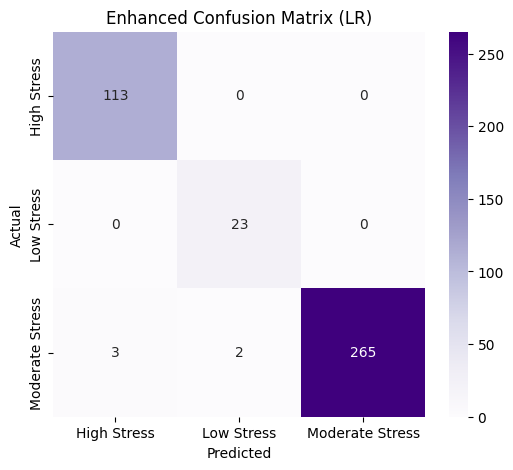

In [ ]:
# ---------------------------
# 1) Predicted vs Actual Scatter Plot
# ---------------------------
plt.figure(figsize=(8,6))
plt.scatter(range(len(y_test)), y_test, label="Actual", alpha=0.7)
plt.scatter(range(len(pred_lr)), pred_lr, label="Predicted", alpha=0.7)
plt.title("Actual vs Predicted Stress Levels (Logistic Regression)")
plt.xlabel("Sample Index")
plt.ylabel("Class (0=Low, 1=Moderate, 2=High)")
plt.legend()
plt.grid(True)
plt.savefig("actual_vs_predicted_lr.png", bbox_inches='tight')
plt.show()

# ---------------------------
# 2) Probability Confidence Plot
# ---------------------------
probs = lr.predict_proba(X_test_scaled)
plt.figure(figsize=(10,6))
for i, cls in enumerate(target_le.classes_):
    plt.plot(probs[:,i], label=f"Prob {cls}")

plt.title("Prediction Confidence for Each Class")
plt.xlabel("Sample Index")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.savefig("probability_confidence_lr.png", bbox_inches='tight')
plt.show()

# ---------------------------
# 3) Enhanced Confusion Matrix
# ---------------------------
cm = confusion_matrix(y_test, pred_lr)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=target_le.classes_,
            yticklabels=target_le.classes_)
plt.title("Enhanced Confusion Matrix (LR)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix_lr.png", bbox_inches='tight')
plt.show()


In [ ]:
# Save classification reports to CSV for submission
rep_rf = classification_report(y_test, pred_rf, target_names=target_le.classes_, output_dict=True)
rep_xgb = classification_report(y_test, pred_xgb, target_names=target_le.classes_, output_dict=True)
rep_lr = classification_report(y_test, pred_lr, target_names=target_le.classes_, output_dict=True)

pd.DataFrame(rep_rf).T.to_csv("report_rf.csv")
pd.DataFrame(rep_xgb).T.to_csv("report_xgb.csv")
pd.DataFrame(rep_lr).T.to_csv("report_lr.csv")

print("Saved reports and pngs. Final best model:", best_name, "acc:", best_acc)


Saved reports and pngs. Final best model: lr acc: 0.9876847290640394


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from fpdf import FPDF
import seaborn as sns
import io
from math import pi

# load model + encoders
model = joblib.load("best_model.pkl")
enc = joblib.load("encoders.pkl")
target_le = enc["target_le"]
feature_cols = enc["feature_cols"]
label_encoders = enc.get("label_encoders", {})
scaler = enc.get("scaler", None)

st.set_page_config(page_title="Student Stress Predictor", layout="wide")
st.markdown("<h1 style='text-align:center'>🎓 Student Academic Stress Predictor</h1>", unsafe_allow_html=True)

# left: details & questionnaire; right: results
left, right = st.columns([2,1])

with left:
    st.header("Student details (optional)")
    # if demographic encoders exist, show selectboxes; else skip
    demo_vals = {}
    for c in ['Age','Gender','Academic_Year','CGPA','Scholarship']:
        if c in label_encoders:
            choices = list(label_encoders[c].classes_)
            demo_vals[c] = st.selectbox(c, choices)
        else:
            demo_vals[c] = None

    st.header("📋 Academic Stress Questionnaire (Use sliders 0=Never → 4=Very Often)")
    questions = [
        "How often have you felt upset due to academic issues?",
        "How often have you felt unable to control academic matters?",
        "How often have you felt nervous and stressed academically?",
        "How often have you felt unable to cope with assignments/exams?",
        "How confident do you feel handling academic problems?",
        "How often do academic things go your way?",
        "How often do you control irritations in academic life?",
        "How often have you felt your academic performance is excellent?",
        "How often do you get angry about grades?",
        "How often do academic difficulties feel overwhelming?"
    ]

    q_vals = []
    cols = st.columns(2)
    for i, q in enumerate(questions,1):
        with cols[i%2]:
            v = st.slider(f"Q{i}. {q}", 0, 4, 2, key=f"q{i}")
            q_vals.append(v)

    if st.button("Predict Stress Level"):
        # build row according to feature_cols order
        row = []
        for c in feature_cols:
            if c.startswith('Q'):
                idx = int(c[1:]) - 1
                row.append(q_vals[idx])
            else:
                # demographic
                if demo_vals.get(c) is None:
                    # if missing, use 0
                    row.append(0)
                else:
                    # transform using saved label encoder
                    le = label_encoders.get(c)
                    if le:
                        row.append(int(le.transform([demo_vals[c]])[0]))
                    else:
                        row.append(0)

        X = np.array(row).reshape(1,-1)
        if scaler is not None:
            X = scaler.transform(X)

        pred = model.predict(X)[0]
        label = target_le.inverse_transform([pred])[0]
        probs = model.predict_proba(X)[0]

        # results on right
        with right:
            st.success(f"🎯 Predicted Stress Level: **{label}**")
            probs_df = pd.DataFrame({'Stress Level': target_le.classes_, 'Probability': probs})
            st.bar_chart(probs_df.set_index('Stress Level'))

            # radar chart
            st.subheader("Stress pattern (radar)")
            categories = [f"Q{i}" for i in range(1,11)]
            values = q_vals + [q_vals[0]]
            angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
            angles += angles[:1]
            fig = plt.figure(figsize=(5,5))
            ax = fig.add_subplot(111, polar=True)
            ax.plot(angles, values, linewidth=2)
            ax.fill(angles, values, alpha=0.3)
            ax.set_xticklabels(categories)
            st.pyplot(fig)

            # show correlation heatmap file if exists
            st.subheader("Correlation heatmap (Q1..Q10)")
            try:
                img = open("corr_heatmap_qs.png","rb").read()
                st.image(img, use_column_width=True)
            except:
                st.write("Heatmap not available.")

            # small student summary
            st.subheader("Student summary")
            s = []
            if sum(q_vals) > 30:
                s.append("🔴 High academic stress tendencies.")
            elif sum(q_vals) < 12:
                s.append("🟢 Low academic stress tendencies.")
            else:
                s.append("🟡 Moderate stress tendencies.")
            if q_vals[4] <= 1:
                s.append("Consider improving confidence in handling academic problems.")
            for line in s:
                st.write(line)

            # PDF report: generate and let user download
            buffer = io.BytesIO()
            pdf = FPDF()
            pdf.add_page()
            pdf.set_font("Arial", size=12)
            pdf.cell(200, 10, txt="Student Stress Analysis Report", ln=True, align='C')
            pdf.ln(5)
            pdf.cell(200,10, txt=f"Predicted Stress Level: {label}", ln=True)
            pdf.ln(4)
            pdf.cell(200,10, txt="Probabilities:", ln=True)
            for lev, p in zip(target_le.classes_, probs):
                pdf.cell(200,8, txt=f"{lev}: {p:.3f}", ln=True)
            pdf.ln(4)
            pdf.cell(200,10, txt="Question scores:", ln=True)
            for i,v in enumerate(q_vals,1):
                pdf.cell(200,8, txt=f"Q{i}: {v}", ln=True)
            pdf.output("stress_report.pdf")
            with open("stress_report.pdf","rb") as f:
                st.download_button("📥 Download PDF report", f, file_name="Stress_Report.pdf")


Writing app.py


In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64


In [ ]:
!python3 -m streamlit run app.py --server.port 8501 &>/content/st.log &


In [ ]:
!tail -n 20 /content/st.log


In [ ]:
!kill -9 $(lsof -t -i:8501) 2>/dev/null
!pkill streamlit 2>/dev/null
!pkill cloudflared 2>/dev/null


In [ ]:
!lsof -i:8501


In [ ]:
!python3 -m streamlit run app.py --server.port 8501 --server.headless true &>/content/st.log &


In [ ]:
!tail -n 30 /content/st.log



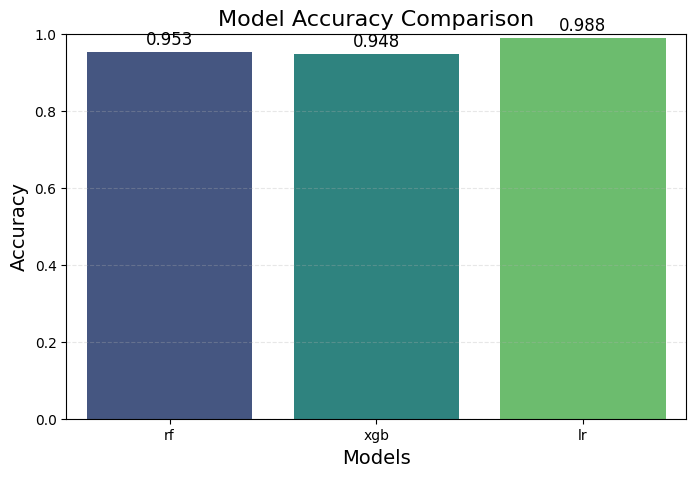

In [ ]:
# ---------------------
# Cell 12 — Visual Accuracy Comparison
# ---------------------

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

model_names = list(accuracies.keys())
model_acc = list(accuracies.values())

sns.barplot(x=model_names, y=model_acc, palette="viridis")

plt.title("Model Accuracy Comparison", fontsize=16)
plt.xlabel("Models", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.3)

for i, acc in enumerate(model_acc):
    plt.text(i, acc + 0.02, f"{acc:.3f}", ha='center', fontsize=12)

plt.show()


In [ ]:
# ---------------------
# Cell X — Accuracy & F1 Score Calculation
# ---------------------

from sklearn.metrics import accuracy_score, f1_score

results = {}

# Random Forest
rf_pred = pred_rf
results["Random Forest"] = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "F1 Macro": f1_score(y_test, rf_pred, average='macro'),
    "F1 Weighted": f1_score(y_test, rf_pred, average='weighted')
}

# XGBoost
xgb_pred = pred_xgb
results["XGBoost"] = {
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "F1 Macro": f1_score(y_test, xgb_pred, average='macro'),
    "F1 Weighted": f1_score(y_test, xgb_pred, average='weighted')
}

# Logistic Regression
lr_pred = pred_lr
results["Logistic Regression"] = {
    "Accuracy": accuracy_score(y_test, lr_pred),
    "F1 Macro": f1_score(y_test, lr_pred, average='macro'),
    "F1 Weighted": f1_score(y_test, lr_pred, average='weighted')
}

results


{'Random Forest': {'Accuracy': 0.9532019704433498,
  'F1 Macro': 0.8909663919323969,
  'F1 Weighted': 0.9532069076807428},
 'XGBoost': {'Accuracy': 0.9482758620689655,
  'F1 Macro': 0.8794203944203945,
  'F1 Weighted': 0.9489079571222429},
 'Logistic Regression': {'Accuracy': 0.9876847290640394,
  'F1 Macro': 0.978629034086529,
  'F1 Weighted': 0.9877782089549438}}

In [ ]:
!./cloudflared-linux-amd64 tunnel --url http://localhost:8501 --no-autoupdate


2026-02-24T13:31:38Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-02-24T13:31:38Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-02-24T13:31:41Z INF +--------------------------------------------------------------------------------------------+
2026-02-24T13:31:41Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-02-24T13:31:41Z INF |  https://costa-camcorders-klein-culture.trycloudflare.